In [18]:
import importlib, NB_config

importlib.reload(NB_config)
from NB_config import *

In [20]:
df = pd.read_csv(DATASET_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 149,485 rows × 24 columns


,business_id,name,city,state,country,country_name,continent,latitude,longitude,stars,...,is_open,address,price_level,description,website,phone,image_url,source,entity_type,popularity
0,680ac5b42a0f865f,Trèsind Studio,Dubai,Dubai,AE,NaN,Asia,25.114932,55.139118,5.0,...,1,NaN,4.0,NaN,https://guide.michelin.com/en/dubai-emirate/du...,NaN,NaN,michelin,restaurant,19.659
1,fb5f7e0a9343ae29,Atrevo,Porto,Porto,PT,NaN,Europe,41.146694,-8.601363,4.0,...,1,NaN,2.0,NaN,https://guide.michelin.com/en/porto-region/por...,NaN,NaN,michelin,restaurant,15.727
2,2ca10f4418f15849,Chocho,Paris,Île-de-France,FR,NaN,Europe,48.875729,2.348994,4.0,...,1,NaN,3.0,NaN,https://guide.michelin.com/en/ile-de-france/pa...,NaN,NaN,michelin,restaurant,15.727


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149485 entries, 0 to 149484
Data columns (total 24 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   149485 non-null  str    
 1   name          149485 non-null  str    
 2   city          149485 non-null  str    
 3   state         58103 non-null   str    
 4   country       149485 non-null  str    
 5   country_name  123037 non-null  str    
 6   continent     149485 non-null  str    
 7   latitude      143835 non-null  float64
 8   longitude     143835 non-null  float64
 9   stars         149485 non-null  float64
 10  review_count  149485 non-null  int64  
 11  categories    149485 non-null  str    
 12  attributes    3751 non-null    str    
 13  hours         1890 non-null    str    
 14  is_open       149485 non-null  int64  
 15  address       128083 non-null  str    
 16  price_level   7501 non-null    float64
 17  description   119405 non-null  str    
 18  website       9

In [22]:
missing = (
    df.isnull()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
image_url,149485,100.00
hours,147595,98.74
attributes,145734,97.49
price_level,141984,94.98
state,91382,61.13
phone,54829,36.68
website,51557,34.49
description,30080,20.12
country_name,26448,17.69
address,21402,14.32


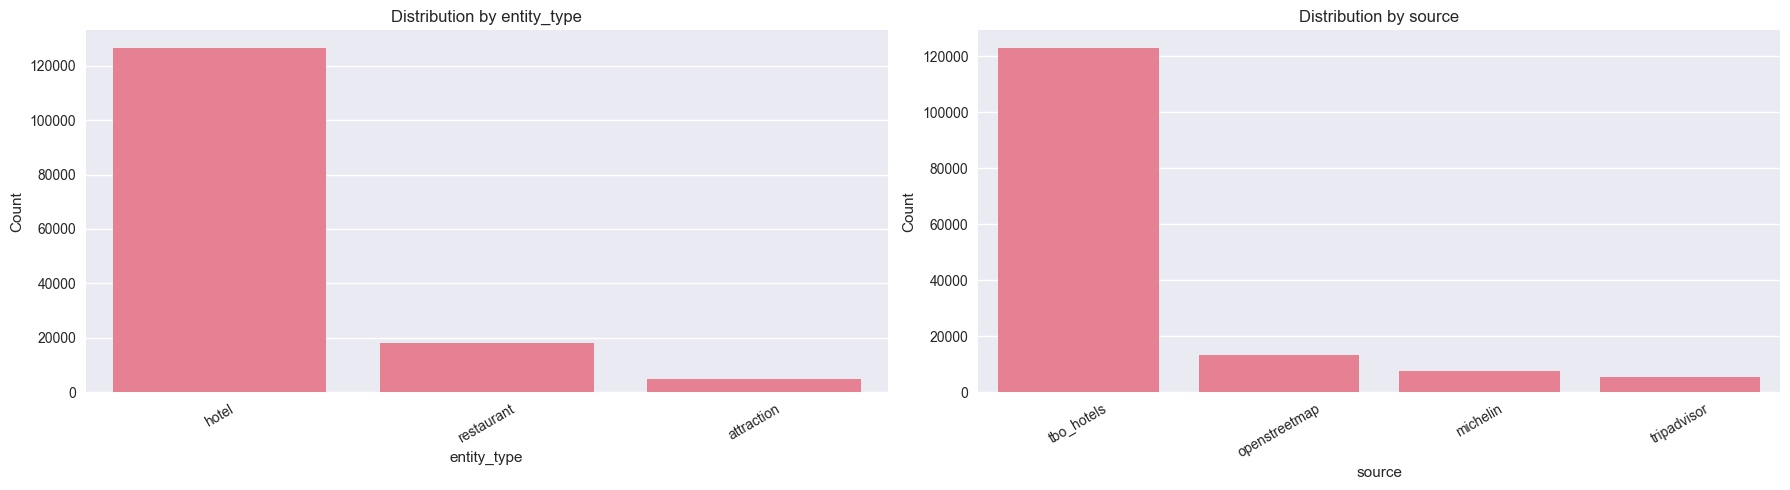

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, col in zip(axes, ["entity_type", "source"]):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"Distribution by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [24]:
num_cols = ["stars", "review_count", "popularity", "price_level"]
df[num_cols].describe().round(2)

,stars,review_count,popularity,price_level
count,149485.00,149485.00,149485.00,7501.00
mean,4.01,2.51,0.82,2.67
std,0.08,10.92,3.58,0.94
min,1.00,0.00,0.00,1.00
25%,4.00,0.00,0.00,2.00
50%,4.00,0.00,0.00,3.00
75%,4.00,0.00,0.00,3.00
max,5.00,50.00,19.66,4.00


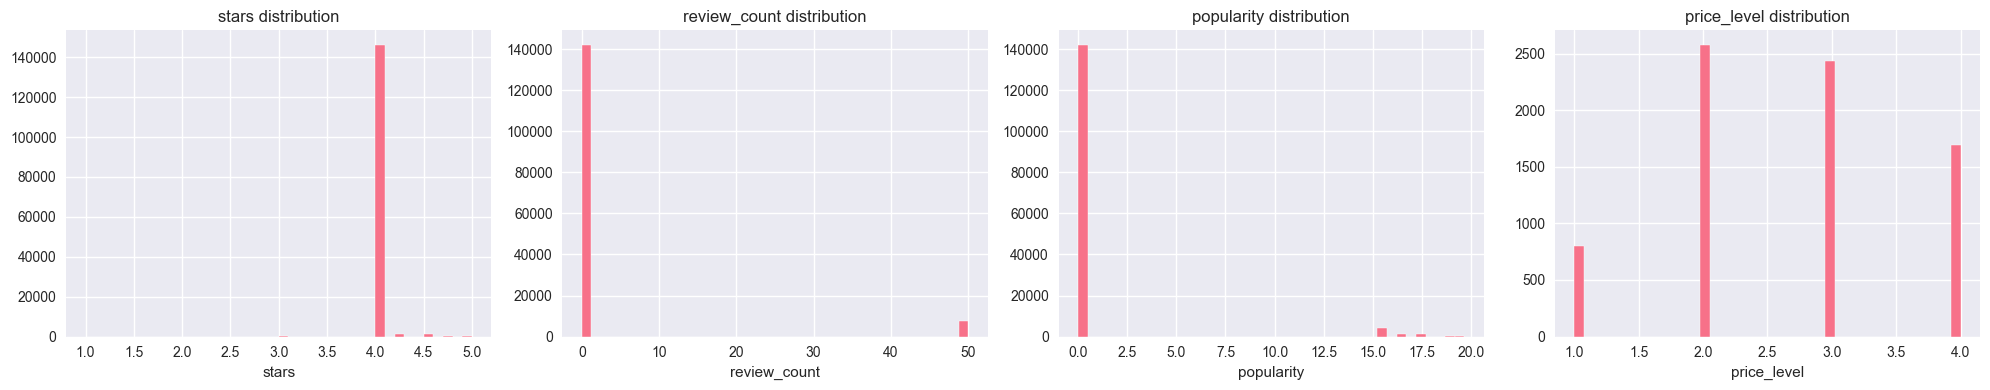

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    df[col].dropna().hist(bins=40, ax=ax, edgecolor="white")
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [26]:
has_coords = df[["latitude", "longitude"]].notnull().all(axis=1)
has_ratings = df["stars"].notnull()

print(f"Rows with coordinates : {has_coords.sum():,} ({has_coords.mean()*100:.1f}%)")
print(f"Rows with star ratings : {has_ratings.sum():,} ({has_ratings.mean()*100:.1f}%)")

Rows with coordinates : 143,835 (96.2%)
Rows with star ratings : 149,485 (100.0%)


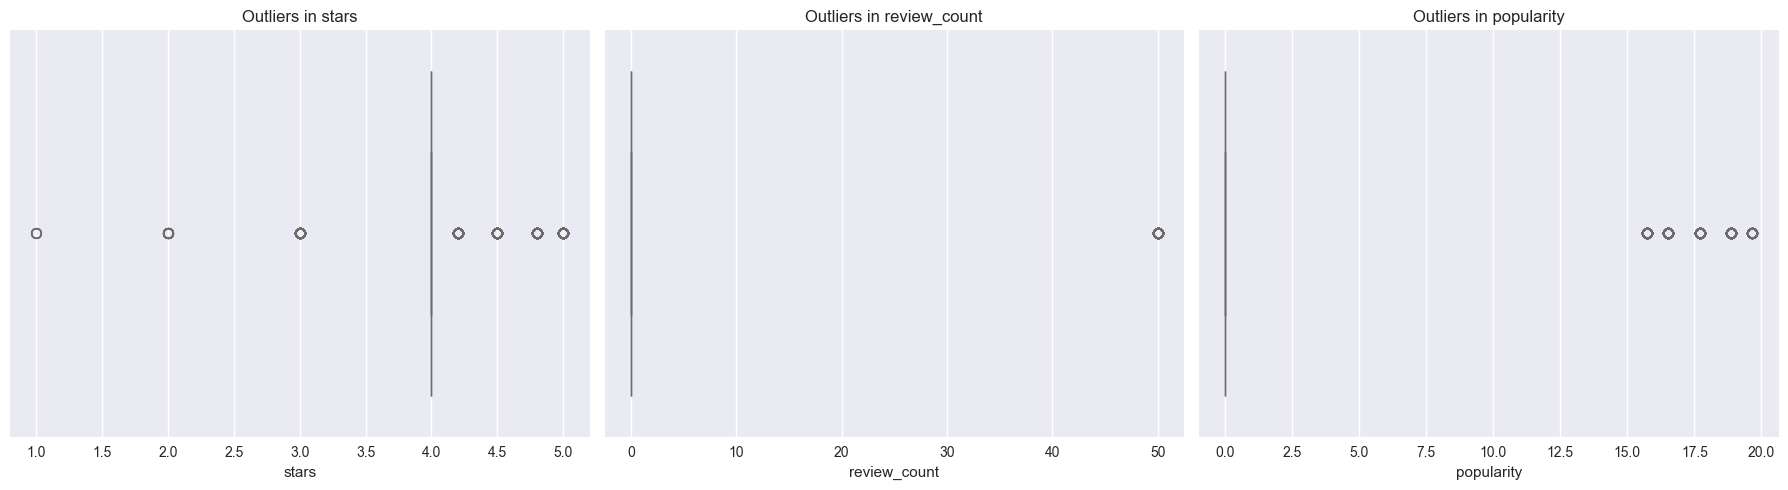

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["stars", "review_count", "popularity"]):
    sns.boxplot(x=df[col].dropna(), ax=ax)
    ax.set_title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

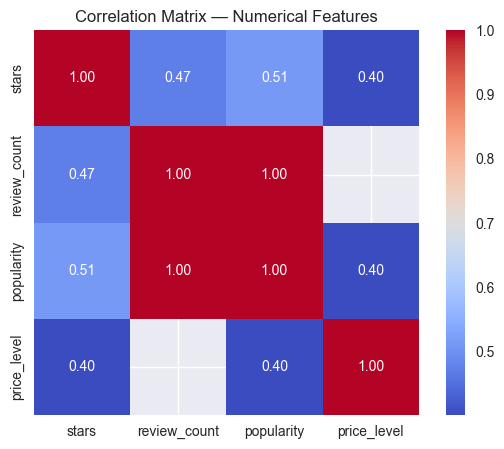

In [28]:
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix — Numerical Features")
plt.show()

In [29]:
print("=== DATASET SUMMARY ===")
print(f"Total records      : {len(df):,}")
print(f"Entity types       : {df['entity_type'].unique()}")
print(f"Sources            : {df['source'].unique()}")
print(f"Countries covered  : {df['country_name'].nunique()}")
print(f"Cities covered     : {df['city'].nunique()}")
print(f"Avg star rating    : {df['stars'].mean():.2f}")
print(f"Median review count: {df['review_count'].median():.0f}")

=== DATASET SUMMARY ===
Total records      : 149,485
Entity types       : <ArrowStringArray>
['restaurant', 'attraction', 'hotel']
Length: 3, dtype: str
Sources            : <ArrowStringArray>
['michelin', 'openstreetmap', 'tbo_hotels', 'tripadvisor']
Length: 4, dtype: str
Countries covered  : 54
Cities covered     : 61
Avg star rating    : 4.01
Median review count: 0
